In [14]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
sys.path.insert(0, "/home/thomasb/")

from albatros_analysis.src.utils import orbcomm_utils as outils

In [15]:
coords = {
        0: [79.417161473, -90.767238685, 187.9577], #MARS1
        1: [79.417198047, -90.758739192, 183.0684], #MARS2
        2: [79.388456412, -91.019202963, 25.1938], #CSA
        3: [79.418302573, -90.667395452, 59.6242], #Mars 5
        4: [79.397984238, -90.799842408, 41.6994], #Mars 6
        5: [79.411474117, -90.695266129, 31.6314], #Mars 7
        6: [79.443757694, -90.718202634, 414.9131] #MARS8
    }
antmap = {0:"MARS1", 1:"MARS2",2:"MARS4",3:"MARS5",4:"MARS6",5:"MARS7",6:"MARS8"}

In [ ]:
pidx = 0

#satellite passes
# fname = f'/scratch/thomasb/pipeline_test_phases/data_with_clock/satpass_{pidx}.npz'
#fname = f'/scratch/thomasb/pipeline_test_phases/data_without_clock/satpass_{pidx}_noclock.npz'
#fname = f'/scratch/thomasb/mapmaking_dumps/clock_corrector_testing/satpass_{pidx}.npz'

#map stuff
#fname = f'/scratch/mohanagr/map_output/jul22_satpass_{pidx}.npz' #without correction
#fname = f'/scratch/thomasb/mapmaking_dumps/all_sats_science_band/satpass_{pidx}.npz' #with correction
#fname = f'/scratch/thomasb/mapmaking_dumps/all_sats_science_band_flipped/satpass_{pidx}.npz' #with FLIPPED correction

#sim
#fname = '/scratch/thomasb/mapmaking_dumps/simulation_vis.npz'

# path_plots = f'/scratch/thomasb/pipeline_test_phases/satpass_{pidx}_plots'
#os.makedirs(path_plots, exist_ok = True)

with np.load(fname) as f:
    print(f)
    vis = f['vis']
    times = f['times']
    freqs = f['freqs']
    #mask = f['mask']

    # vis = f['data']
    # times = f['utc']
    # freqs = np.arange(360*64, 392*64)/64 * 250e6/4096

NpzFile '/scratch/thomasb/mapmaking_dumps/clock_corrector_testing/satpass_0.npz' with keys: vis, mask, times, freqs


In [30]:
print('vis shape', vis.shape)
print('utc pass shape', times.shape)
print('start of pass', times[0])
print('dt', times[1]-times[0])
print('freqs shape', freqs.shape)
print('start freq', freqs[0])
print('df', freqs[1]-freqs[0])

vis shape (1964, 21, 72)
utc pass shape (1964,)
start of pass 1753204686.5445898
dt 0.0671088695526123
freqs shape (72,)
start freq 138061523.4375
df -15258.7890625


In [31]:
times[0]-1753200150

np.float64(4536.544589757919)

In [32]:
ntimes, nchans, nbl = vis.shape
print(vis.shape)
tle_path = outils.get_tle_file(times[0], "/project/rrg-sievers/mohanagr/OCOMM_TLES")
triu_idx=np.triu_indices(7,k=1)

(1964, 21, 72)


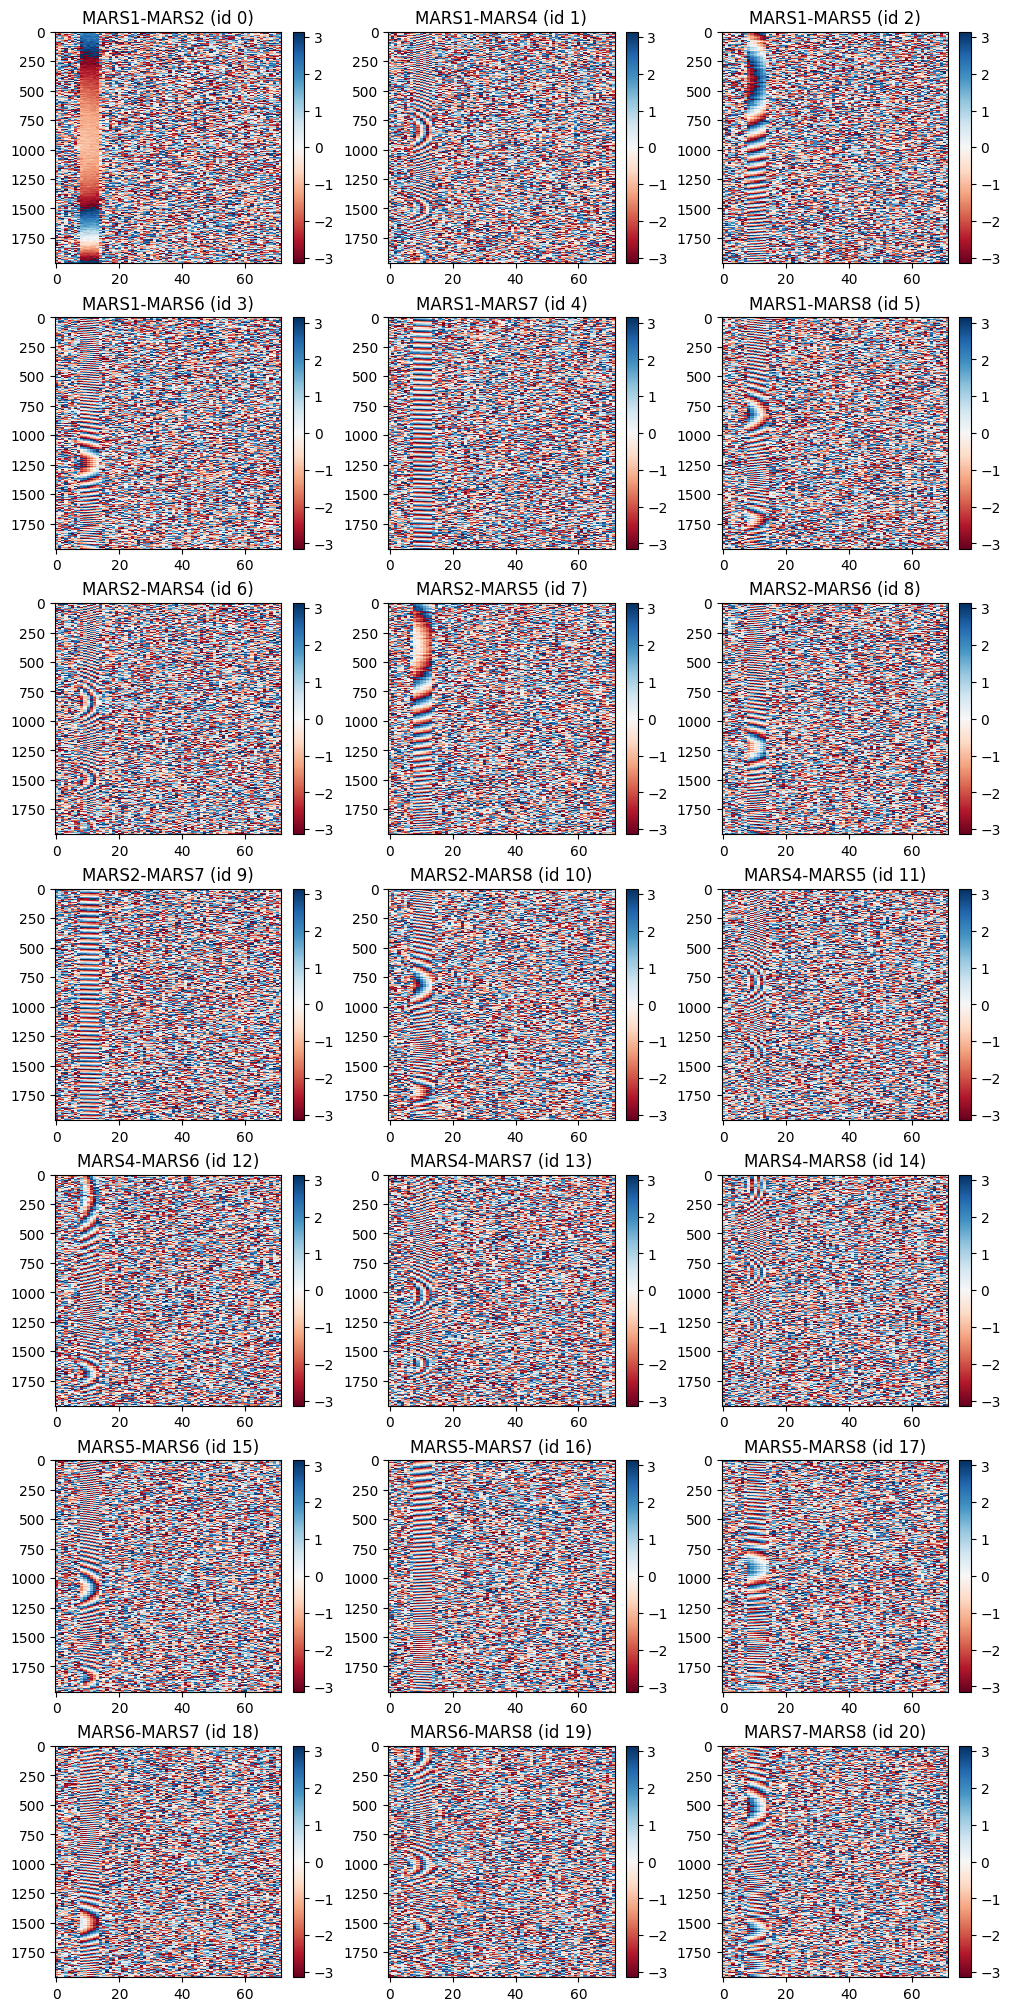

In [33]:
antmap = {0:"MARS1", 1:"MARS2",2:"MARS4",3:"MARS5",4:"MARS6",5:"MARS7",6:"MARS8"}
fig,ax = plt.subplots(7,3, constrained_layout=True)
fig.set_size_inches(10,20)
ax=np.ravel(ax)

blnum=0
for i in range(len(antmap)):
        for j in range(i+1, len(antmap)):
            ax[blnum].set_title(f"{antmap[i]}-{antmap[j]} (id {blnum})")
            #img=ax[blnum].imshow(np.angle(vis[:,:,blnum]),aspect='auto',interpolation='none',cmap='RdBu')
            img=ax[blnum].imshow(np.angle(vis[:,blnum,:]),aspect='auto',interpolation='none',cmap='RdBu')
            cbar=plt.colorbar(img,ax=ax[blnum])
            blnum+=1

3 4
MARS5 MARS6
Frequency 137.8936767578125 MHz
catalog #57166 epoch 2025-07-22 18:35:47 UTC
one delay prediction: 0.06637167930603027


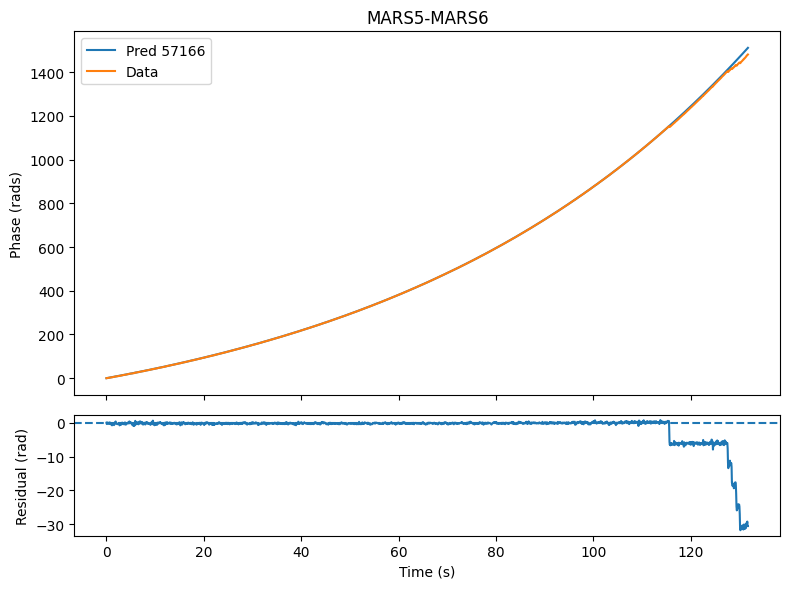

In [35]:
#for blid in range(nbl):
blid = 15
#sat = 59051
sat = 57166
ant1_idx, ant2_idx = triu_idx[0][blid], triu_idx[1][blid]
name1, name2 = antmap[ant1_idx], antmap[ant2_idx]
coord1, coord2 = coords[ant1_idx], coords[ant2_idx]
print(ant1_idx, ant2_idx)
print(name1, name2)

chanid = 11
freq = freqs[chanid]
print('Frequency', freq / 1e6, 'MHz')

# measured data
#angle_meas = np.angle(vis[:, chanid, blid])   #(ntimes, nchan, nbl)
angle_meas = np.angle(vis[:, blid, chanid])  #(ntimes, nbl, nchan)
phase_meas = np.unwrap(angle_meas) - angle_meas[0]

# predicted data
niter = int(times[-1] - times[0]) + 2
dt = times[1] - times[0]

d = outils.get_sat_delay(coord1, coord2, tle_path, times[0], niter, sat)
delays = np.interp(np.arange(0, ntimes) * dt, np.arange(0, niter), d)
angle_pred = -2 * np.pi * freq * delays
phase_pred = angle_pred - angle_pred[0]

# residuals
residuals = phase_meas - phase_pred

# plot it
fig, (ax1, ax2) = plt.subplots(2, 1,figsize=(8, 6),sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# phase
ax1.plot(times - times[0], phase_pred, label=f'Pred {sat}')
ax1.plot(times - times[0], phase_meas, label='Data')
ax1.set_ylabel('Phase (rads)')
ax1.set_title(f'{name1}-{name2}')
ax1.legend()

# residuals
ax2.plot(times - times[0], residuals)
ax2.axhline(0, linestyle='--')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Residual (rad)')

plt.tight_layout()
    # path_plot = os.path.join(path_plots, f'{name1}_{name2}.png')
    # fig.savefig(path_plot)
    # plt.close(fig)